<a href="https://colab.research.google.com/github/e23046/Statistical-Learning-e23046/blob/main/Assignment%201/Q9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Probability Space (Ω, F, P)

Given the sample space:
Ω = {G1, G2, D1, D2}

The σ-algebra F is the power set of Ω, F = P(Ω), which includes all possible subsets of Ω.

The probabilities are:
P({G1})=0.50
P({G2})=0.20
P({D1})=0.10
P({D2})=0.20

### Discrete Random Variables

**X records only whether the item is good or defective:**
X(G1)=0, X(G2)=0, X(D1)=1, X(D2)=1

**Y records both quality and machine:**
Y(G1)=1, Y(G2)=2, Y(D1)=3, Y(D2)=4

### σ-algebra generated by X, σ(X)

The range of X is {0, 1}.
The preimages of X are:
$X^{-1}(0)$ = {ω ∈ Ω | X(ω) = 0} = {G1, G2}
$X^{-1}(1)$ = {ω ∈ Ω | X(ω) = 1} = {D1, D2}

σ(X) is the smallest σ-algebra containing all preimages of measurable sets in the range of X. In this case, it means all sets formed by these preimages and their complements, and Ω and ∅.

σ(X) = {∅, Ω, {G1, G2}, {D1, D2}}

### σ-algebra generated by Y, σ(Y)

The range of Y is {1, 2, 3, 4}.
The preimages of Y are:
$Y^{-1}(1)$ = {ω ∈ Ω | Y(ω) = 1} = {G1}
$Y^{-1}(2)$ = {ω ∈ Ω | Y(ω) = 2} = {G2}
$Y^{-1}(3)$ = {ω ∈ Ω | Y(ω) = 3} = {D1}
$Y^{-1}(4)$ = {ω ∈ Ω | Y(ω) = 4} = {D2}

σ(Y) is the smallest σ-algebra containing all preimages of measurable sets in the range of Y. Since each outcome in Ω maps to a unique value of Y, the preimages are the singletons of Ω. Therefore, σ(Y) is the power set of Ω, P(Ω).

σ(Y) = {∅, Ω, {G1}, {G2}, {D1}, {D2}, {G1, G2}, {G1, D1}, {G1, D2}, {G2, D1}, {G2, D2}, {D1, D2}, {G1, G2, D1}, {G1, G2, D2}, {G1, D1, D2}, {G2, D1, D2}}

### Show that σ(X) ⊆ σ(Y), and explain why Y contains more information than X.

We observe that {G1, G2} and {D1, D2} are elements of σ(Y). Since ∅ and Ω are also in σ(Y), it follows that all elements of σ(X) are also elements of σ(Y). Therefore, σ(X) ⊆ σ(Y).

Y contains more information than X because it distinguishes between all individual outcomes in Ω (G1, G2, D1, D2). For example, knowing Y=1 tells us exactly that the outcome was G1. However, X only tells us whether the product is good (X=0) or defective (X=1). If X=0, we know the product is good, but we don't know if it's G1 or G2. Y's values provide a finer-grained partition of the sample space, meaning it preserves more detail about the original events.


In [1]:
import pandas as pd

# Define the sample space, probabilities, and mappings for X and Y
omega = ['G1', 'G2', 'D1', 'D2']
probabilities = {'G1': 0.50, 'G2': 0.20, 'D1': 0.10, 'D2': 0.20}

map_X = {'G1': 0, 'G2': 0, 'D1': 1, 'D2': 1}
map_Y = {'G1': 1, 'G2': 2, 'D1': 3, 'D2': 4}

# Create a DataFrame for easier computation
df = pd.DataFrame({
    'outcome': omega,
    'P_outcome': [probabilities[o] for o in omega],
    'X_value': [map_X[o] for o in omega],
    'Y_value': [map_Y[o] for o in omega]
})

print("DataFrame representing the sample space and random variables:")
display(df)


DataFrame representing the sample space and random variables:


,outcome,P_outcome,X_value,Y_value
0,G1,0.5,0,1
1,G2,0.2,0,2
2,D1,0.1,1,3
3,D2,0.2,1,4


### Find the marginal distribution of X.


In [2]:
# Marginal distribution of X
dist_X = df.groupby('X_value')['P_outcome'].sum().reset_index()
dist_X.rename(columns={'P_outcome': 'P(X=x)'}, inplace=True)
print("Marginal Distribution of X:")
display(dist_X)


Marginal Distribution of X:


,X_value,P(X=x)
0,0,0.7
1,1,0.3


### Find the marginal distribution of Y.


In [3]:
# Marginal distribution of Y
dist_Y = df.groupby('Y_value')['P_outcome'].sum().reset_index()
dist_Y.rename(columns={'P_outcome': 'P(Y=y)'}, inplace=True)
print("Marginal Distribution of Y:")
display(dist_Y)


Marginal Distribution of Y:


,Y_value,P(Y=y)
0,1,0.5
1,2,0.2
2,3,0.1
3,4,0.2


### Compute the joint probabilities
P(X=0,Y=1), P(X=0,Y=2), P(X=1,Y=3), P(X=1,Y=4).


In [4]:
# Joint probabilities P(X=x, Y=y)
joint_probs = df.groupby(['X_value', 'Y_value'])['P_outcome'].sum().reset_index()
joint_probs.rename(columns={'P_outcome': 'P(X=x, Y=y)'}, inplace=True)
print("Joint Probabilities P(X=x, Y=y):")
display(joint_probs)

# Specific joint probabilities requested
P_X0_Y1 = joint_probs[(joint_probs['X_value'] == 0) & (joint_probs['Y_value'] == 1)]['P(X=x, Y=y)'].values[0]
P_X0_Y2 = joint_probs[(joint_probs['X_value'] == 0) & (joint_probs['Y_value'] == 2)]['P(X=x, Y=y)'].values[0]
P_X1_Y3 = joint_probs[(joint_probs['X_value'] == 1) & (joint_probs['Y_value'] == 3)]['P(X=x, Y=y)'].values[0]
P_X1_Y4 = joint_probs[(joint_probs['X_value'] == 1) & (joint_probs['Y_value'] == 4)]['P(X=x, Y=y)'].values[0]

print(f"P(X=0, Y=1) = {P_X0_Y1}")
print(f"P(X=0, Y=2) = {P_X0_Y2}")
print(f"P(X=1, Y=3) = {P_X1_Y3}")
print(f"P(X=1, Y=4) = {P_X1_Y4}")


Joint Probabilities P(X=x, Y=y):


,X_value,Y_value,"P(X=x, Y=y)"
0,0,1,0.5
1,0,2,0.2
2,1,3,0.1
3,1,4,0.2


P(X=0, Y=1) = 0.5
P(X=0, Y=2) = 0.2
P(X=1, Y=3) = 0.1
P(X=1, Y=4) = 0.2


### Compute the conditional probabilities
P(X=1∣Y=3), P(X=1∣Y=4), P(Y=3∣X=1), P(Y=4∣X=1).

Recall the formula for conditional probability: $P(A|B) = P(A \cap B) / P(B)$.


In [5]:
# Helper function to get probability from a distribution DataFrame
def get_prob(df_dist, value_col, prob_col, value):
    return df_dist[df_dist[value_col] == value][prob_col].values[0]

# P(X=1 | Y=3) = P(X=1, Y=3) / P(Y=3)
P_Y3 = get_prob(dist_Y, 'Y_value', 'P(Y=y)', 3)
P_X1_given_Y3 = P_X1_Y3 / P_Y3 if P_Y3 != 0 else 0
print(f"P(X=1 | Y=3) = P(X=1, Y=3) / P(Y=3) = {P_X1_Y3} / {P_Y3} = {P_X1_given_Y3}")

# P(X=1 | Y=4) = P(X=1, Y=4) / P(Y=4)
P_Y4 = get_prob(dist_Y, 'Y_value', 'P(Y=y)', 4)
P_X1_given_Y4 = P_X1_Y4 / P_Y4 if P_Y4 != 0 else 0
print(f"P(X=1 | Y=4) = P(X=1, Y=4) / P(Y=4) = {P_X1_Y4} / {P_Y4} = {P_X1_given_Y4}")

# P(Y=3 | X=1) = P(X=1, Y=3) / P(X=1)
P_X1 = get_prob(dist_X, 'X_value', 'P(X=x)', 1)
P_Y3_given_X1 = P_X1_Y3 / P_X1 if P_X1 != 0 else 0
print(f"P(Y=3 | X=1) = P(X=1, Y=3) / P(X=1) = {P_X1_Y3} / {P_X1} = {P_Y3_given_X1}")

# P(Y=4 | X=1) = P(X=1, Y=4) / P(X=1)
P_Y4_given_X1 = P_X1_Y4 / P_X1 if P_X1 != 0 else 0
print(f"P(Y=4 | X=1) = P(X=1, Y=4) / P(X=1) = {P_X1_Y4} / {P_X1} = {P_Y4_given_X1}")


P(X=1 | Y=3) = P(X=1, Y=3) / P(Y=3) = 0.1 / 0.1 = 1.0
P(X=1 | Y=4) = P(X=1, Y=4) / P(Y=4) = 0.2 / 0.2 = 1.0
P(Y=3 | X=1) = P(X=1, Y=3) / P(X=1) = 0.1 / 0.30000000000000004 = 0.3333333333333333
P(Y=4 | X=1) = P(X=1, Y=4) / P(X=1) = 0.2 / 0.30000000000000004 = 0.6666666666666666


### Interpret the difference between conditioning on X and conditioning on Y.

**Conditioning on Y (e.g., P(X=1 | Y=3))**:
When we condition on Y, we are given very specific information about the outcome. For example, `Y=3` tells us precisely that the product is defective AND it was produced on Machine 1 (D1). Given this exact knowledge, calculating `P(X=1 | Y=3)` becomes trivial: if we know it's D1, then it *must* be defective (X=1), so the probability is 1.0. This shows that knowing Y's value often directly determines X's value because Y provides a more granular view of the underlying event.

**Conditioning on X (e.g., P(Y=3 | X=1))**:
When we condition on X, we have less specific information. For example, `X=1` tells us the product is defective, but it doesn't specify which machine produced it. It could be D1 or D2. Therefore, `P(Y=3 | X=1)` asks for the probability that it was from Machine 1, *given that it was defective*. This probability will be less than 1 (unless one of the defective categories has zero probability), as we are distributing the probability among the possible defective outcomes (D1 and D2).

In essence, conditioning on Y often removes all uncertainty about X, while conditioning on X usually leaves some uncertainty about Y because Y differentiates between events that X groups together.


### Explain, in words, what information is available in σ(X) but not in σ(Y), and what information is available in σ(Y) but not in σ(X).

*   **Information available in σ(X) but not in σ(Y):**
    There is **no** information available in σ(X) that is not also available in σ(Y). Since σ(X) is a subset of σ(Y), any event (piece of information) that can be expressed using X can also be expressed using Y. σ(X) allows us to distinguish between the event of being 'good' ({G1, G2}) and the event of being 'defective' ({D1, D2}). These exact sets are also present in σ(Y).

*   **Information available in σ(Y) but not in σ(X):**
    σ(Y) contains much more detailed information than σ(X). Specifically, σ(Y) allows us to distinguish between individual outcomes in the sample space. For example, σ(Y) can tell us:
    *   Whether the product is G1 (good, Machine 1).
    *   Whether the product is G2 (good, Machine 2).
    *   Whether the product is D1 (defective, Machine 1).
    *   Whether the product is D2 (defective, Machine 2).

    σ(X), on the other hand, cannot differentiate between G1 and G2 (it only knows they are 'good'), nor can it differentiate between D1 and D2 (it only knows they are 'defective'). Thus, σ(Y) provides information about *both* quality and the machine of production, whereas σ(X) only provides information about quality.


### Give a Python based visualization of the model.

We can visualize the sample space, the probabilities, and how X and Y map to these outcomes.


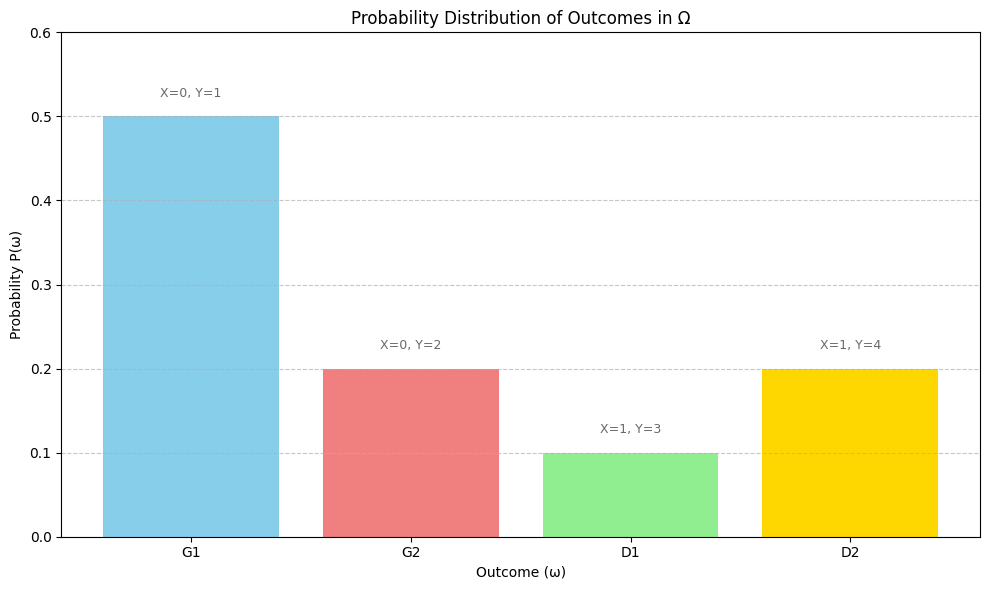


Mapping of Outcomes to X and Y values:


,Probability,X Value (Good/Defective),Y Value (Quality & Machine)
Outcome,,,
G1,0.5,0,1
G2,0.2,0,2
D1,0.1,1,3
D2,0.2,1,4


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data for visualization
outcomes = df['outcome'].tolist()
probs = df['P_outcome'].tolist()
X_values = df['X_value'].tolist()
Y_values = df['Y_value'].tolist()

fig, ax = plt.subplots(figsize=(10, 6))

# Plotting probabilities of each outcome
bars = ax.bar(outcomes, probs, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])

ax.set_xlabel('Outcome (ω)')
ax.set_ylabel('Probability P(ω)')
ax.set_title('Probability Distribution of Outcomes in Ω')
ax.set_ylim(0, 0.6)

# Annotate bars with X and Y values
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'X={X_values[i]}, Y={Y_values[i]}',
            ha='center', va='bottom', fontsize=9, color='dimgray')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Another way to visualize the mapping
print("\nMapping of Outcomes to X and Y values:")
mapping_table = pd.DataFrame({
    'Outcome': outcomes,
    'Probability': probs,
    'X Value (Good/Defective)': X_values,
    'Y Value (Quality & Machine)': Y_values
})
display(mapping_table.set_index('Outcome'))


### Find the marginal, joint, and conditional Shannon Entropy of X and Y.

We will use the definition of Shannon entropy:
$H(Z) = - \sum_{z} P(Z=z) \log_2 P(Z=z)$

Joint Entropy:
$H(X, Y) = - \sum_{x,y} P(X=x, Y=y) \log_2 P(X=x, Y=y)$

Conditional Entropy:
$H(Y|X) = - \sum_{x,y} P(X=x, Y=y) \log_2 P(Y=y|X=x)$
Also, $H(Y|X) = H(X,Y) - H(X)$


In [7]:
from scipy.stats import entropy
import numpy as np

# --- Marginal Entropy H(X) ---
P_X = dist_X['P(X=x)'].values
H_X = entropy(P_X, base=2)
print(f"Marginal Entropy H(X) = {H_X:.4f} bits")

# --- Marginal Entropy H(Y) ---
P_Y = dist_Y['P(Y=y)'].values
H_Y = entropy(P_Y, base=2)
print(f"Marginal Entropy H(Y) = {H_Y:.4f} bits")

# --- Joint Entropy H(X, Y) ---
# The joint probabilities P(X=x, Y=y) are effectively the initial P(omega_i) because Y uniquely determines X
# and (X,Y) pairs map directly to omega_i

# Filter out (X,Y) pairs that have 0 probability (e.g., X=0, Y=3 is impossible)
# The `joint_probs` DataFrame already contains only the non-zero joint probabilities from the initial setup.
joint_prob_values = joint_probs['P(X=x, Y=y)'].values
H_XY = entropy(joint_prob_values, base=2)
print(f"Joint Entropy H(X, Y) = {H_XY:.4f} bits")

# Alternatively, we can calculate H_XY directly from the original probabilities:
H_XY_alt = entropy(df['P_outcome'].values, base=2)
print(f"Joint Entropy H(X, Y) (from P(omega)) = {H_XY_alt:.4f} bits (should be the same)")

# --- Conditional Entropy H(Y|X) ---
# H(Y|X) = H(X,Y) - H(X)
H_Y_given_X = H_XY - H_X
print(f"Conditional Entropy H(Y|X) = H(X,Y) - H(X) = {H_XY:.4f} - {H_X:.4f} = {H_Y_given_X:.4f} bits")

# --- Conditional Entropy H(X|Y) ---
# H(X|Y) = H(X,Y) - H(Y)
H_X_given_Y = H_XY - H_Y
print(f"Conditional Entropy H(X|Y) = H(X,Y) - H(Y) = {H_XY:.4f} - {H_Y:.4f} = {H_X_given_Y:.4f} bits")


print("\nInterpretation of Entropy values:")
print(f"- H(X) = {H_X:.4f}: Average uncertainty in determining if a product is good or defective.")
print(f"- H(Y) = {H_Y:.4f}: Average uncertainty in determining both the quality and machine of production. This is higher than H(X) because Y provides more detailed outcomes.")
print(f"- H(X,Y) = {H_XY:.4f}: Average uncertainty in determining the specific outcome (G1, G2, D1, D2). This is equal to H(Y) because Y already specifies the individual outcomes, and given Y, X is determined.")
print(f"- H(Y|X) = {H_Y_given_X:.4f}: Average uncertainty remaining about Y (quality and machine) when X (good/defective) is known. This is greater than 0 because knowing X doesn't fully determine Y (e.g., if X=0, it could be Y=1 or Y=2).")
print(f"- H(X|Y) = {H_X_given_Y:.4f}: Average uncertainty remaining about X (good/defective) when Y (quality and machine) is known. This is 0 because knowing Y completely determines X (e.g., if Y=1, X must be 0; if Y=3, X must be 1).")


Marginal Entropy H(X) = 0.8813 bits
Marginal Entropy H(Y) = 1.7610 bits
Joint Entropy H(X, Y) = 1.7610 bits
Joint Entropy H(X, Y) (from P(omega)) = 1.7610 bits (should be the same)
Conditional Entropy H(Y|X) = H(X,Y) - H(X) = 1.7610 - 0.8813 = 0.8797 bits
Conditional Entropy H(X|Y) = H(X,Y) - H(Y) = 1.7610 - 1.7610 = 0.0000 bits

Interpretation of Entropy values:
- H(X) = 0.8813: Average uncertainty in determining if a product is good or defective.
- H(Y) = 1.7610: Average uncertainty in determining both the quality and machine of production. This is higher than H(X) because Y provides more detailed outcomes.
- H(X,Y) = 1.7610: Average uncertainty in determining the specific outcome (G1, G2, D1, D2). This is equal to H(Y) because Y already specifies the individual outcomes, and given Y, X is determined.
- H(Y|X) = 0.8797: Average uncertainty remaining about Y (quality and machine) when X (good/defective) is known. This is greater than 0 because knowing X doesn't fully determine Y (e.g.